# Setup

This notebook is inteded to run on Google Colab

In [ ]:
!pip install pyalex
!pip install opinionated
!pip install datamapplot
!pip install graph-tools

  Preparing metadata (setup.py) ... done
  Created wheel for pytess: filename=Pytess-1.0.0-py3-none-any.whl size=11831 sha256=2e71e98b1aceb109f9e3e34dda77b3444fb57a6544165f806e1f839ad0725978
  Stored in directory: /root/.cache/pip/wheels/d9/cd/dc/05269c4a9e27b4e65cc1bda70f1b0fab8bcd39b1d04ff0a521
Successfully built pytess


In [ ]:
# https://openalex.org/

from pyalex import Works, Authors, Sources, Institutions, Concepts, Publishers, Funders
import pyalex
# pyalex.config.email = "maximilian.noichl@uni-bamberg.de"
from itertools import chain
from tqdm.auto import tqdm

from pyalex import Works
import pandas as pd

import networkx as nx
import json
#from compress_pickle import dump, load

from itertools import combinations

# Network Construction Functions

## Extending Records Functions

In [ ]:
# goes from the record of the original query to the record that includes all papers cited
def generate_extended_citation_records(df):
  all_referenced_works = [x for y in df['referenced_works'] for x in y]

# all_unique_referenced_works = list(set(all_referenced_works))

# from collections import Counter

# def remove_less_frequent_items(lst, n):
#     counts = Counter(lst)
#     return [item for item in lst if counts[item] > n]

# # Set to 0 for full set:
# n = 0
# filtered_referenced_works = remove_less_frequent_items(all_referenced_works, n) # remove
# print(len(filtered_referenced_works))

  filtered_referenced_works = list(set(all_referenced_works)) #remove duplicates from download list.
  additional_works_to_download = [x for x in filtered_referenced_works if x not in  df['id']]

  all_aditional_records =[]
  block_len = 99
  # Loop in blocks of 50
  for i in tqdm(range(0, len(additional_works_to_download), block_len)):
      sublist = additional_works_to_download[i:i+block_len]
      ID_str = "|".join([x.replace('https://openalex.org/','') for  x in sublist])
      record_list = Works().filter(openalex_id=ID_str).get(per_page=block_len)
      #print(len(record_list))
      for this_record in record_list:
          all_aditional_records.append(this_record)

  all_additional_records_df = pd.DataFrame(all_aditional_records)
  total_records = pd.concat([df, all_additional_records_df])

  return total_records


## Generate Citation Network

In [ ]:
# Create a directed graph
def generate_citation_network(df):

  G = nx.DiGraph() # This line was not indented correctly, causing the error.


  # Add nodes and edges
  for ix,row in tqdm(df.iterrows()):
      for author in row['authorships']:
          this_author = author['author']['id']

          if this_author not in G.nodes():
              G.add_node(this_author)
              G.nodes()[this_author]['authored_paper_count'] = 1
              G.nodes()[this_author]['cited_count'] = 0
              G.nodes()[this_author]['titles'] = [row['title']]


          else:
              G.nodes()[this_author]['authored_paper_count'] += 1
              G.nodes()[this_author]['titles'].append(row['title'])


          for cited_work_id in row["referenced_works"]:
              cited_work = df[df['id'] == cited_work_id] # This fails silently if citations are not present!
              if len(cited_work) >= 1: # In case of multiple hits (shouldn't happen once sampling is fixed)
                  cited_work = cited_work.iloc[0]

              for cited_author in cited_work['authorships']:
                  cited_author = cited_author['author']['id']

                  if cited_author not in G.nodes():
                      G.add_node(cited_author)
                      G.nodes()[cited_author]['cited_count'] = 1
                      G.nodes()[cited_author]['authored_paper_count'] = 0
                      G.nodes()[cited_author]['titles'] = [cited_work['title']]

                  else:
                      G.nodes()[cited_author]['cited_count'] += 1
                      G.nodes()[cited_author]['titles'].append(cited_work['title'])


                  if G.has_edge(this_author, cited_author):  
                      # edges go FROM citing TO cited
                      # this is compatible with how the model is defined
                      # this is compatible with the networkx function that calculates in-degree
                      G[this_author][cited_author]['weight'] += 1
                  else:
                      G.add_edge(this_author, cited_author, weight=1)

  return G

## Generating Co-Author Function

In [ ]:
# Inputs a dataframe of records, and outputs a co-authorship network, where two nodes are connected if they co-authored something
# Create a directed graph
def generate_coauthor_network(df):

  G = nx.Graph() # This line was not indented correctly, causing the error.

  # Add nodes and edges
  for ix,row in tqdm(df.iterrows()):
      for author in row['authorships']:
          this_author = author['author']['id']
          author_name = author['author']['display_name']

          if this_author not in G.nodes():
              G.add_node(this_author)
              G.nodes()[this_author]['authored_paper_count'] = 1
              G.nodes()[this_author]['author_name'] = author_name
              G.nodes()[this_author]['titles'] = [row['title']]

          else:
              G.nodes()[this_author]['authored_paper_count'] += 1
              G.nodes()[this_author]['titles'].append(row['title'])

      author_ids = [entry['author']['id'] for entry in row['authorships']]
      pairs = list(combinations(author_ids, 2))
      for pair in pairs:
          if G.has_edge(pair[0], pair[1]):  # edges go FROM citing TO cited
              G[pair[0]][pair[1]]['weight'] += 1
          else:
              G.add_edge(pair[0], pair[1], weight=1)

  return G

## Cleaning Functions

In [ ]:
def remove_duplicate_nodes_directed(G, consider='both'):
    """
    Remove duplicate nodes in a directed graph based on neighbors.

    Parameters:
    - G: The directed graph (DiGraph).
    - consider: 'both', 'outgoing', or 'incoming' to specify which neighbors to consider for duplication.
    """
    # Dictionary to map neighbor sets to a representative node
    neighbor_dict = {}

    for node in list(G.nodes):
        if consider == 'outgoing':
            # Use only outgoing neighbors
            neighbors = frozenset(G.successors(node))
        elif consider == 'incoming':
            # Use only incoming neighbors
            neighbors = frozenset(G.predecessors(node))
        else:
            # Use both incoming and outgoing neighbors as a single set
            outgoing_neighbors = frozenset(G.successors(node))
            incoming_neighbors = frozenset(G.predecessors(node))
            # Union of incoming and outgoing neighbors
            neighbors = incoming_neighbors.union(outgoing_neighbors)
        if neighbors in neighbor_dict:
            # Remove the current node if it's a duplicate
            G.remove_node(node)
        else:
            # Keep the node as a representative for this neighbor configuration
            neighbor_dict[neighbors] = node

    return G

In [ ]:
def remove_duplicate_nodes_undirected(G, consider='both'):
    """
    Remove duplicate nodes in a directed graph based on neighbors.

    Parameters:
    - G: The directed graph (DiGraph).
    - consider: 'both', 'outgoing', or 'incoming' to specify which neighbors to consider for duplication.
    """
    # Dictionary to map neighbor sets to a representative node
    neighbor_dict = {}

    for node in list(G.nodes):
        if consider == 'outgoing':
            # Use only outgoing neighbors
            neighbors = frozenset(G.successors(node))
        elif consider == 'incoming':
            # Use only incoming neighbors
            neighbors = frozenset(G.predecessors(node))
        else:
            # Use both incoming and outgoing neighbors as a single set
            outgoing_neighbors = frozenset(G.successors(node))
            incoming_neighbors = frozenset(G.predecessors(node))
            # Union of incoming and outgoing neighbors
            neighbors = incoming_neighbors.union(outgoing_neighbors)
        if neighbors in neighbor_dict:
            # Remove the current node if it's a duplicate
            G.remove_node(node)
        else:
            # Keep the node as a representative for this neighbor configuration
            neighbor_dict[neighbors] = node

    return G

In [ ]:
def get_connected_component(G):
  # Extract largest component:
  largest_cc = max(nx.weakly_connected_components(G), key=len)
  G = G.subgraph(largest_cc)
  return G

## Plotting Network Functions

In [ ]:
# Plotting functions
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def plot_network_degree_distribution(G, title):
    degrees = np.array([degree for node, degree in G.degree()])
    # Create the histogram with a KDE
    sns.set(style="whitegrid")
    plt.figure(figsize=(8, 6))
    sns.histplot(degrees, kde=False, bins=150, stat="count")
    # Calculate the mean
    mean_value = np.mean(degrees)
    print(mean_value)
    print(np.median(degrees))

    # Plot a vertical line at the mean value
    plt.axvline(mean_value, color='b', linestyle='--', linewidth=2)
    plt.text(mean_value + 0.1, plt.ylim()[1] * 0.9, 'Mean: {:.2f}'.format(mean_value), color='b')

    plt.title('Timeline Smooth Histogram for: ' + title)
    plt.xlabel('Degree')
    plt.ylabel('Count')
    plt.xticks(fontsize=8,rotation=20)
    plt.show()

def plot_loglog(G,m=10):
    degree_freq = nx.degree_histogram(G)
    degrees = range(len(degree_freq))
    plt.figure(figsize=(12, 8))
    plt.loglog(degrees[m:], degree_freq[m:],'go-')
    plt.xlabel('Degree')
    plt.ylabel('Frequency')


In [ ]:
### Its in the workings

import graph_tools as gt
#from graph_tool.all import *

# def map_graph_to_graph_tool(G):
#   # Convert NetworkX graph to graph_tool graph
#   g = gt.Graph(directed=True)

#   # Create a mapping from NetworkX nodes to graph_tool vertices
#   node_map = {n: g.add_vertex() for n in G.nodes()}

#   # Add edges to the graph_tool graph
#   for u, v in G.edges():
#       g.add_edge(node_map[u], node_map[v])

#   # Optionally, you can print the graph_tool graph's vertices and edges to verify
#   print("Nodes in the graph_tool network:")
#   print(g.num_vertices())
#   print("Edges in the graph_tool network:")
#   print(g.num_edges())

#   return g

# def plot_graph_tool(g):
#   #g = extract_largest_component(g, directed=False)
#   pos = sfdp_layout(g)
#   dprms = dict(fmt="png",  output_size=(1200, 1200))
#   graph_draw(g, pos, **dprms)
#         #    , vertex_fill_color=g.vp.value, vcmap=matplotlib.cm.coolwarm,
#         #    vcnorm=matplotlib.colors.Normalize(vmin=0, vmax=1), **dprms)

# Perceptron

## Query

In [ ]:
# https://openalex.org/works?page=1&filter=default.search%3A%22Personality%22%20AND%20%22Life%20Outcomes%22
# Create a query with the specified search terms
query = Works().search(['Perceptron']).filter(publication_year="<1979")
#.search(['"Personality" AND "Life outcomes"']).filter(publication_year=">2020")

records= []
for record in chain(*query.paginate(per_page=99,n_max=None)):
    records.append(record)
    #print(len(records))
print(len(records))

695


In [ ]:
df = pd.DataFrame(records)
print(df.columns)
df.head()

Index(['id', 'doi', 'title', 'display_name', 'relevance_score',
       'publication_year', 'publication_date', 'ids', 'language',
       'primary_location', 'type', 'type_crossref', 'indexed_in',
       'open_access', 'authorships', 'institution_assertions',
       'countries_distinct_count', 'institutions_distinct_count',
       'corresponding_author_ids', 'corresponding_institution_ids', 'apc_list',
       'apc_paid', 'fwci', 'has_fulltext', 'fulltext_origin', 'cited_by_count',
       'citation_normalized_percentile', 'cited_by_percentile_year', 'biblio',
       'is_retracted', 'is_paratext', 'primary_topic', 'topics', 'keywords',
       'concepts', 'mesh', 'locations_count', 'locations', 'best_oa_location',
       'sustainable_development_goals', 'grants', 'datasets', 'versions',
       'referenced_works_count', 'referenced_works', 'related_works',
       'abstract_inverted_index', 'cited_by_api_url', 'counts_by_year',
       'updated_date', 'created_date'],
      dtype='object')


,id,doi,title,display_name,relevance_score,publication_year,publication_date,ids,language,primary_location,...,datasets,versions,referenced_works_count,referenced_works,related_works,abstract_inverted_index,cited_by_api_url,counts_by_year,updated_date,created_date
0,https://openalex.org/W2040870580,https://doi.org/10.1037/h0042519,The perceptron: A probabilistic model for info...,The perceptron: A probabilistic model for info...,6819.3430,1958,1958-01-01,{'openalex': 'https://openalex.org/W2040870580...,en,"{'is_oa': False, 'landing_page_url': 'https://...",...,[],[],15,"[https://openalex.org/W1570445666, https://ope...","[https://openalex.org/W4387297750, https://ope...",None,https://api.openalex.org/works?filter=cites:W2...,"[{'year': 2024, 'cited_by_count': 621}, {'year...",2024-11-04T22:21:41.015350,2016-06-24
1,https://openalex.org/W2086789740,None,Perceptrons: An Introduction to Computational ...,Perceptrons: An Introduction to Computational ...,4632.7534,1969,1969-01-01,{'openalex': 'https://openalex.org/W2086789740...,en,"{'is_oa': False, 'landing_page_url': 'http://c...",...,[],[],0,[],"[https://openalex.org/W3207342693, https://ope...","{'Cambridge,': [0], 'Mass.:': [1], 'MIT': [2],...",https://api.openalex.org/works?filter=cites:W2...,"[{'year': 2024, 'cited_by_count': 50}, {'year'...",2024-11-10T01:11:37.479576,2016-06-24
2,https://openalex.org/W2008353316,https://doi.org/10.2307/1419730,Principles of Neurodynamics: Perceptrons and t...,Principles of Neurodynamics: Perceptrons and t...,3419.4468,1963,1963-12-01,{'openalex': 'https://openalex.org/W2008353316...,en,"{'is_oa': False, 'landing_page_url': 'https://...",...,[],[],0,[],"[https://openalex.org/W2931662336, https://ope...","{'Abstract': [0], ':': [1], 'Part': [2, 104, 1...",https://api.openalex.org/works?filter=cites:W2...,"[{'year': 2024, 'cited_by_count': 16}, {'year'...",2024-11-13T04:26:22.616390,2016-06-24
3,https://openalex.org/W4233045210,https://doi.org/10.21236/ad0256582,PRINCIPLES OF NEURODYNAMICS. PERCEPTRONS AND T...,PRINCIPLES OF NEURODYNAMICS. PERCEPTRONS AND T...,2394.6145,1961,1961-03-15,{'openalex': 'https://openalex.org/W4233045210...,en,"{'is_oa': False, 'landing_page_url': 'https://...",...,[],[],0,[],"[https://openalex.org/W3194278305, https://ope...",None,https://api.openalex.org/works?filter=cites:W4...,"[{'year': 2024, 'cited_by_count': 81}, {'year'...",2024-11-08T19:30:02.206826,2022-05-12
4,https://openalex.org/W2011815965,https://doi.org/10.1001/archpsyc.1962.01720030...,Principles of Neurodynamics. Perceptrons and t...,Principles of Neurodynamics. Perceptrons and t...,1435.8622,1962,1962-09-01,{'openalex': 'https://openalex.org/W2011815965...,en,"{'is_oa': False, 'landing_page_url': 'https://...",...,[],[],0,[],"[https://openalex.org/W45198419, https://opena...","{'In': [0, 87], 'recent': [1], 'years,': [2], ...",https://api.openalex.org/works?filter=cites:W2...,"[{'year': 2024, 'cited_by_count': 10}, {'year'...",2024-11-04T08:01:53.674991,2016-06-24


In [ ]:
raw_df = df.copy()

## Generating Citation Network

In [ ]:
total_records_set = generate_extended_citation_records(df)

  0%|          | 0/51 [00:00<?, ?it/s]

In [ ]:
G = generate_citation_network(total_records_set)

0it [00:00, ?it/s]

In [ ]:
# # Optionally, you can print the nodes and edges to verify
print("Nodes in the network:")
print(len(G.nodes()))
# print("Edges in the network:")
# print(len(G.edges()))
G.nodes(data=True)
print("Edges in the network:")
print(len(G.edges()))

Nodes in the network:
6511
Edges in the network:
36244


## Generate Coauthor Network

In [ ]:
G_coauth = generate_coauthor_network(total_records_set)

0it [00:00, ?it/s]

In [ ]:
# # Optionally, you can print the nodes and edges to verify
print("Nodes in the network:")
print(len(G_coauth.nodes()))
# print("Edges in the network:")
# print(len(G.edges()))
G_coauth.nodes(data=True)
print("Edges in the network:")
print(len(G_coauth.edges()))

Nodes in the network:
6511
Edges in the network:
5885


## Cleaning and Plotting

11.133159268929504
5.0


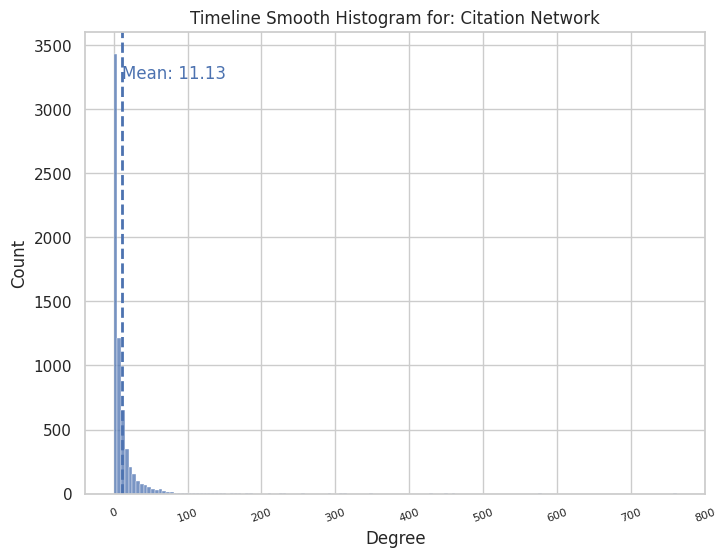

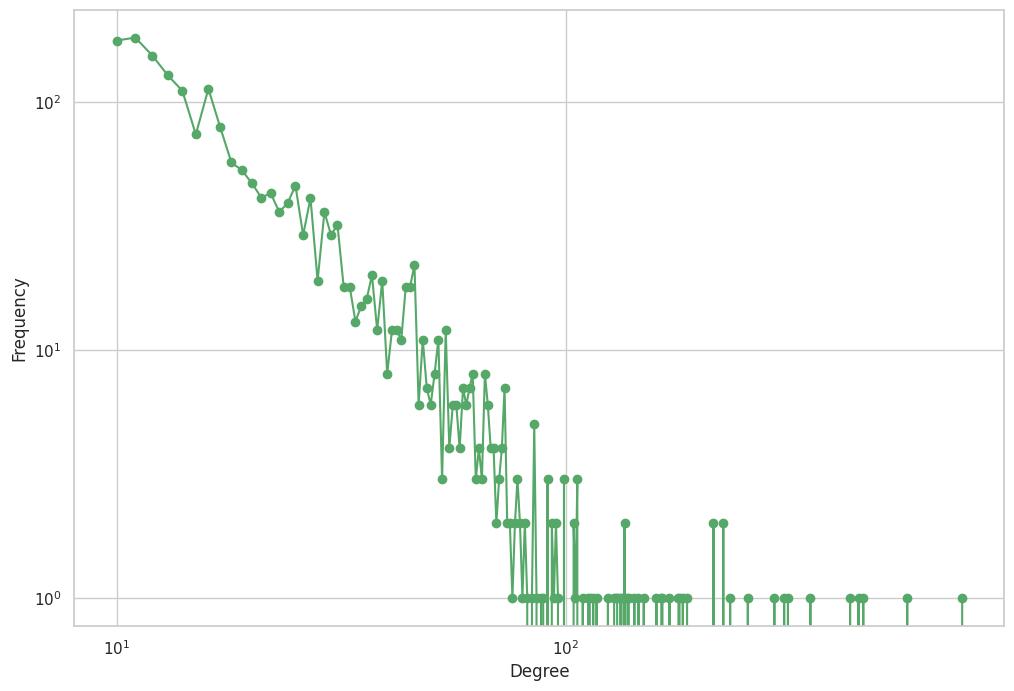

In [ ]:
plot_network_degree_distribution(G, "Citation Network")
plot_loglog(G)

1.8077100291813855
1.0


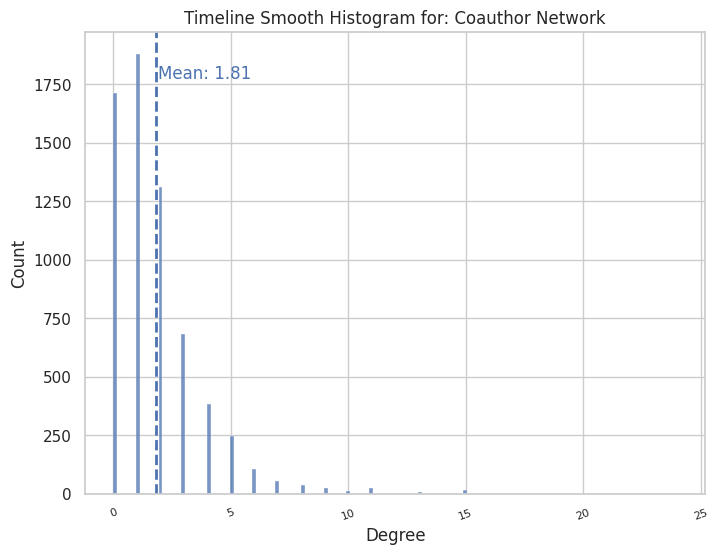

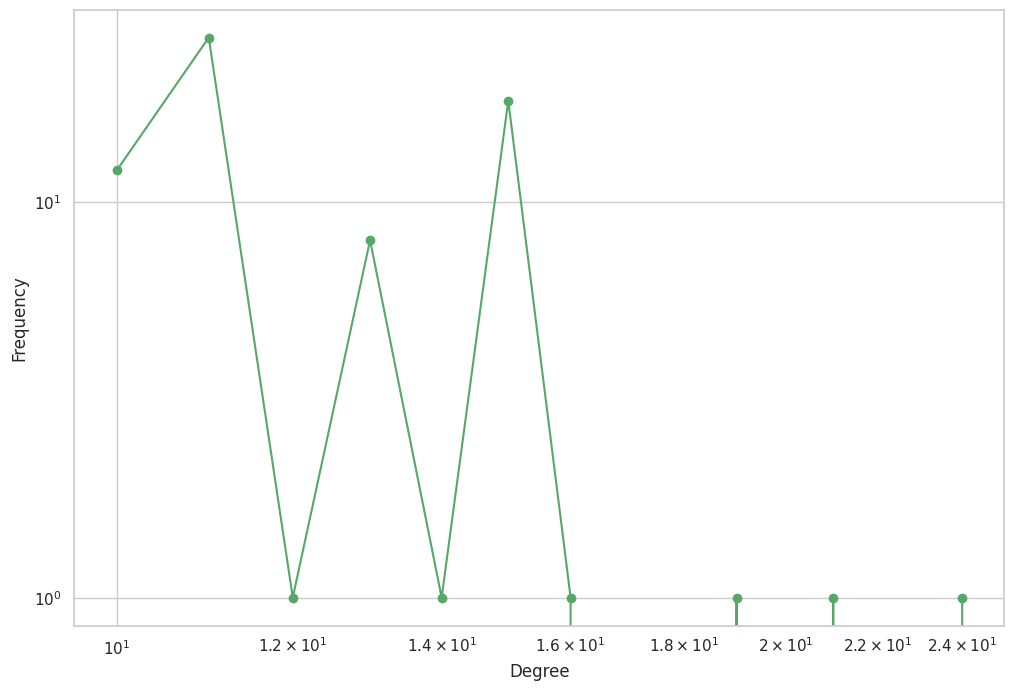

In [ ]:
plot_network_degree_distribution(G_coauth, "Coauthor Network")
plot_loglog(G_coauth)

# Peptic Ulcer

## Query

### Standard Query

In [ ]:
# https://openalex.org/works?page=1&filter=default.search%3A%22Personality%22%20AND%20%22Life%20Outcomes%22
# Create a query with the specified search terms
# "Although other reports of successful treatment with antibiotics or observation of bacteria in the stomach occasionally surfaced, the bacterial hypothesis was not seriously investigated until the late 1970s.
# At the 1978 meeting of the American Gastroenterology Association, it appeared that tide had begun to turn.""
query = Works().search(['peptic ulcer']).filter(publication_year="<1978")
#.search(['"Personality" AND "Life outcomes"']).filter(publication_year=">2020")

records= []
for record in chain(*query.paginate(per_page=99,n_max=None)):
    records.append(record)

KeyboardInterrupt: 

### Query Out of an URL Query in Open Alex

In [ ]:
from urllib.parse import urlparse, parse_qs

def openalex_url_to_pyalex_query(url):
    """
    Convert an OpenAlex search URL to a pyalex query.

    Args:
    url (str): The OpenAlex search URL.

    Returns:
    tuple: (Works object, dict of parameters)
    """
    parsed_url = urlparse(url)
    query_params = parse_qs(parsed_url.query)

    # Initialize the Works object
    query = Works()

    # Handle filters
    if 'filter' in query_params:
        filters = query_params['filter'][0].split(',')
        for f in filters:
            if ':' in f:
                key, value = f.split(':', 1)
                if key == 'default.search':
                    query = query.search(value)
                else:
                    query = query.filter(**{key: value})

    # Handle sort
    if 'sort' in query_params:
        sort_params = query_params['sort'][0].split(',')
        for s in sort_params:
            if s.startswith('-'):
                query = query.sort(**{s[1:]: 'desc'})
            else:
                query = query.sort(**{s: 'asc'})

    # Handle other parameters
    params = {}
    for key in ['page', 'per-page', 'sample', 'seed']:
        if key in query_params:
            params[key] = query_params[key][0]

    return query, params



OA_query = "https://openalex.org/works?page=1&filter=publication_year%3A1900-1978,title_and_abstract.search%3A%22peptic%20ulcer%22,cited_by_count%3A%3E1&zoom=w2462873067"

query, params = openalex_url_to_pyalex_query(OA_query)
query_length = query.count()
print(f'Requesting {query_length} entries...')

records = []

for i, record in enumerate(chain(*query.paginate(per_page=200))):
    records.append(record)

Requesting 4081 entries...


### Data Frame

In [ ]:
df = pd.DataFrame(records)
print(df.columns)
df.head()

Index(['id', 'doi', 'title', 'display_name', 'relevance_score',
       'publication_year', 'publication_date', 'ids', 'language',
       'primary_location', 'type', 'type_crossref', 'indexed_in',
       'open_access', 'authorships', 'institution_assertions',
       'countries_distinct_count', 'institutions_distinct_count',
       'corresponding_author_ids', 'corresponding_institution_ids', 'apc_list',
       'apc_paid', 'fwci', 'has_fulltext', 'fulltext_origin', 'cited_by_count',
       'citation_normalized_percentile', 'cited_by_percentile_year', 'biblio',
       'is_retracted', 'is_paratext', 'primary_topic', 'topics', 'keywords',
       'concepts', 'mesh', 'locations_count', 'locations', 'best_oa_location',
       'sustainable_development_goals', 'grants', 'datasets', 'versions',
       'referenced_works_count', 'referenced_works', 'related_works',
       'abstract_inverted_index', 'cited_by_api_url', 'counts_by_year',
       'updated_date', 'created_date'],
      dtype='object')


,id,doi,title,display_name,relevance_score,publication_year,publication_date,ids,language,primary_location,...,datasets,versions,referenced_works_count,referenced_works,related_works,abstract_inverted_index,cited_by_api_url,counts_by_year,updated_date,created_date
0,https://openalex.org/W2462873067,https://doi.org/10.1016/s0140-6736(75)93174-8,PEPTIC ULCER,PEPTIC ULCER,440.57913,1975,1975-05-01,{'openalex': 'https://openalex.org/W2462873067...,en,"{'is_oa': False, 'landing_page_url': 'https://...",...,[],[],3,"[https://openalex.org/W1980097264, https://ope...","[https://openalex.org/W4389568370, https://ope...",None,https://api.openalex.org/works?filter=cites:W2...,"[{'year': 2021, 'cited_by_count': 2}, {'year':...",2024-10-16T17:08:10.276338,2016-07-22
1,https://openalex.org/W1976754613,https://doi.org/10.1056/nejm197602262940905,Nonassociation of Adrenocorticosteroid Therapy...,Nonassociation of Adrenocorticosteroid Therapy...,411.84613,1976,1976-02-26,{'openalex': 'https://openalex.org/W1976754613...,en,"{'is_oa': False, 'landing_page_url': 'https://...",...,[],[],53,"[https://openalex.org/W1467875944, https://ope...","[https://openalex.org/W3199975325, https://ope...","{'IT': [0], 'is': [1, 6, 35], '""known""': [2], ...",https://api.openalex.org/works?filter=cites:W1...,"[{'year': 2024, 'cited_by_count': 2}, {'year':...",2024-10-18T12:45:01.547675,2016-06-24
2,https://openalex.org/W2318051686,https://doi.org/10.1056/nejm197402282900901,"Cigarettes, Alcohol, Coffee and Peptic Ulcer","Cigarettes, Alcohol, Coffee and Peptic Ulcer",376.41500,1974,1974-02-28,{'openalex': 'https://openalex.org/W2318051686...,en,"{'is_oa': False, 'landing_page_url': 'https://...",...,[],[],16,"[https://openalex.org/W1548484032, https://ope...","[https://openalex.org/W3032156516, https://ope...","{'Abstract': [0], 'The': [1], 'relation': [2, ...",https://api.openalex.org/works?filter=cites:W2...,"[{'year': 2024, 'cited_by_count': 2}, {'year':...",2024-10-07T10:06:56.587525,2016-06-24
3,https://openalex.org/W1976875134,https://doi.org/10.1001/jama.1973.03220170019004,"Hypertension, Peptic Ulcer, and Diabetes in Ai...","Hypertension, Peptic Ulcer, and Diabetes in Ai...",357.08360,1973,1973-04-23,{'openalex': 'https://openalex.org/W1976875134...,en,"{'is_oa': False, 'landing_page_url': 'https://...",...,[],[],5,"[https://openalex.org/W2020360663, https://ope...","[https://openalex.org/W645983410, https://open...","{'The': [0, 37], 'hypothesis': [1, 72], 'that'...",https://api.openalex.org/works?filter=cites:W1...,"[{'year': 2024, 'cited_by_count': 1}, {'year':...",2024-11-02T22:29:21.206632,2016-06-24
4,https://openalex.org/W2073910916,https://doi.org/10.1097/00000658-192304000-00006,THE EXPERIMENTAL PRODUCTION OF PEPTIC ULCER,THE EXPERIMENTAL PRODUCTION OF PEPTIC ULCER,352.13130,1923,1923-04-01,{'openalex': 'https://openalex.org/W2073910916...,en,"{'is_oa': False, 'landing_page_url': 'https://...",...,[],[],1,[https://openalex.org/W2018932967],"[https://openalex.org/W4389568370, https://ope...",None,https://api.openalex.org/works?filter=cites:W2...,"[{'year': 2023, 'cited_by_count': 3}, {'year':...",2024-10-30T03:20:51.185925,2016-06-24


In [ ]:
raw_df = df.copy()

## Generating Citation Network

In [ ]:
total_records_set = generate_extended_citation_records(df)

  0%|          | 0/290 [00:00<?, ?it/s]

In [ ]:
G = generate_citation_network(total_records_set)

In [ ]:
# # Optionally, you can print the nodes and edges to verify
print("Nodes in the network:")
print(len(G.nodes()))
# print("Edges in the network:")
# print(len(G.edges()))
G.nodes(data=True)
print("Edges in the network:")
print(len(G.edges()))

## Generate Coauthor Network

In [ ]:
G_coauth = generate_coauthor_network(total_records_set)

In [ ]:
# # Optionally, you can print the nodes and edges to verify
print("Nodes in the network:")
print(len(G_coauth.nodes()))
# print("Edges in the network:")
# print(len(G.edges()))
G_coauth.nodes(data=True)
print("Edges in the network:")
print(len(G_coauth.edges()))

## Cleaning and Plotting

In [ ]:
plot_network_degree_distribution(G, "Citation Network")
plot_loglog(G)

In [ ]:
plot_network_degree_distribution(G_coauth, "Coauthor Network")
plot_loglog(G_coauth)

# Experimental

In [ ]:
# Extract largest component:
largest_cc = max(nx.weakly_connected_components(G), key=len)
G = G.subgraph(largest_cc)

4.346689400397841
1.0


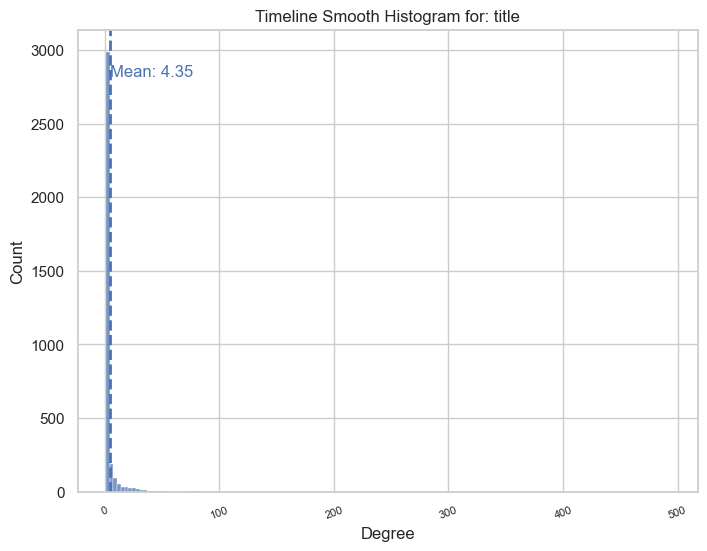

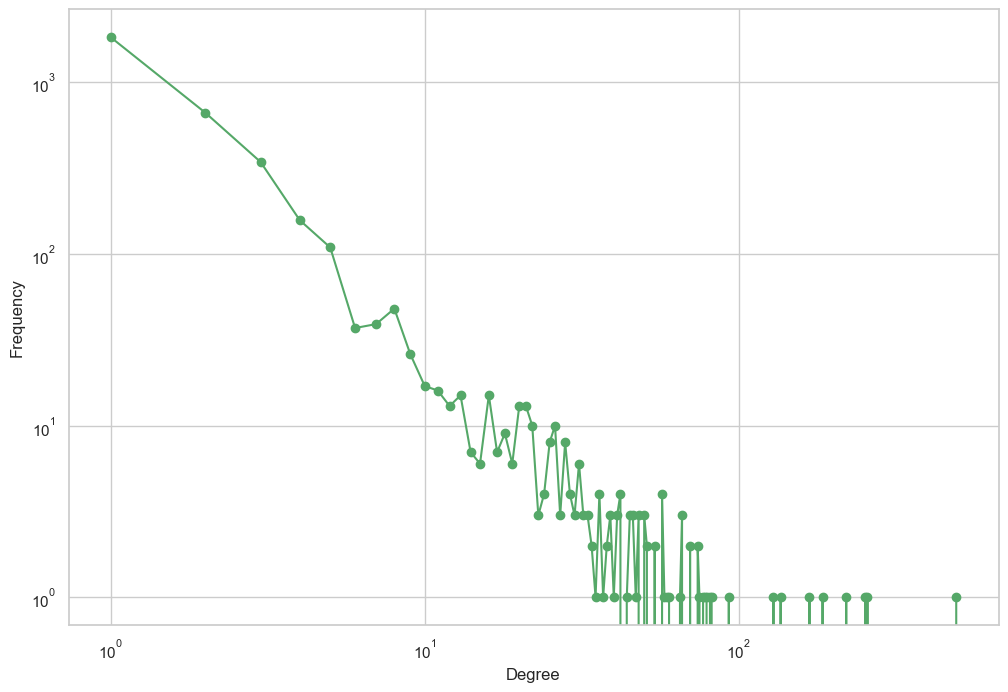

In [ ]:
# Plotting functions
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def plot_network_degree_distribution(G, title):
    degrees = np.array([degree for node, degree in G.degree()])
    # Create the histogram with a KDE
    sns.set(style="whitegrid")
    plt.figure(figsize=(8, 6))
    sns.histplot(degrees, kde=False, bins=150, stat="count")
    # Calculate the mean
    mean_value = np.mean(degrees)
    print(mean_value)
    print(np.median(degrees))

    # Plot a vertical line at the mean value
    plt.axvline(mean_value, color='b', linestyle='--', linewidth=2)
    plt.text(mean_value + 0.1, plt.ylim()[1] * 0.9, 'Mean: {:.2f}'.format(mean_value), color='b')

    plt.title('Timeline Smooth Histogram for: ' + title)
    plt.xlabel('Degree')
    plt.ylabel('Count')
    plt.xticks(fontsize=8,rotation=20)
    plt.show()

def plot_loglog(G,m=10):
    degree_freq = nx.degree_histogram(G)
    degrees = range(len(degree_freq))
    plt.figure(figsize=(12, 8))
    plt.loglog(degrees[m:], degree_freq[m:],'go-')
    plt.xlabel('Degree')
    plt.ylabel('Frequency')

plot_network_degree_distribution(G, 'title')
plot_loglog(G,m=1)

In [ ]:
nodes_with_one_link = [node for node, degree in G.degree() if degree <= 1]

G_more_than_one_link = G.copy()
#G_more_than_one_link.remove_nodes_from(nodes_with_one_link)


In [ ]:
print("Nodes in the network:")
print(len(G_more_than_one_link.nodes()))

print("Edges in the network:")
print(len(G_more_than_one_link.edges()))

Nodes in the network:
3519
Edges in the network:
7648


In [ ]:
#conda install -c conda-forge graph-tool


In [ ]:
import dill

# Use dill to deserialize the graph from a file
with open('perceptron_graph_pre_1979.pkl', 'rb') as f:
    G_loaded = dill.load(f)
#print(G_loaded.nodes(data=True))


def remove_duplicate_nodes_directed(G, consider='both'):
    """
    Remove duplicate nodes in a directed graph based on neighbors.

    Parameters:
    - G: The directed graph (DiGraph).
    - consider: 'both', 'outgoing', or 'incoming' to specify which neighbors to consider for duplication.
    """
    # Dictionary to map neighbor sets to a representative node
    neighbor_dict = {}

    for node in list(G.nodes):
        if consider == 'outgoing':
            # Use only outgoing neighbors
            neighbors = frozenset(G.successors(node))
        elif consider == 'incoming':
            # Use only incoming neighbors
            neighbors = frozenset(G.predecessors(node))
        else:
            # Use both incoming and outgoing neighbors as a single set
            outgoing_neighbors = frozenset(G.successors(node))
            incoming_neighbors = frozenset(G.predecessors(node))
            # Union of incoming and outgoing neighbors
            neighbors = incoming_neighbors.union(outgoing_neighbors)
        if neighbors in neighbor_dict:
            # Remove the current node if it's a duplicate
            G.remove_node(node)
        else:
            # Keep the node as a representative for this neighbor configuration
            neighbor_dict[neighbors] = node

    return G


print(len([node for node in G_loaded.nodes if G_loaded.degree(node) == 0]))
G_loaded = remove_duplicate_nodes_directed(G_loaded.copy())

G_more_than_one_link, G = G_loaded.copy(), G_loaded.copy()

0


In [ ]:
import graph_tool.all as gt

# Convert NetworkX graph to graph_tool graph
g = gt.Graph(directed=True)

# Create a mapping from NetworkX nodes to graph_tool vertices
node_map = {n: g.add_vertex() for n in G_more_than_one_link.nodes()}

# Add edges to the graph_tool graph
for u, v in G_more_than_one_link.edges():
    g.add_edge(node_map[u], node_map[v])

# Optionally, you can print the graph_tool graph's vertices and edges to verify
print("Nodes in the graph_tool network:")
print(g.num_vertices())
print("Edges in the graph_tool network:")
print(g.num_edges())

Nodes in the graph_tool network:
943
Edges in the graph_tool network:
3374


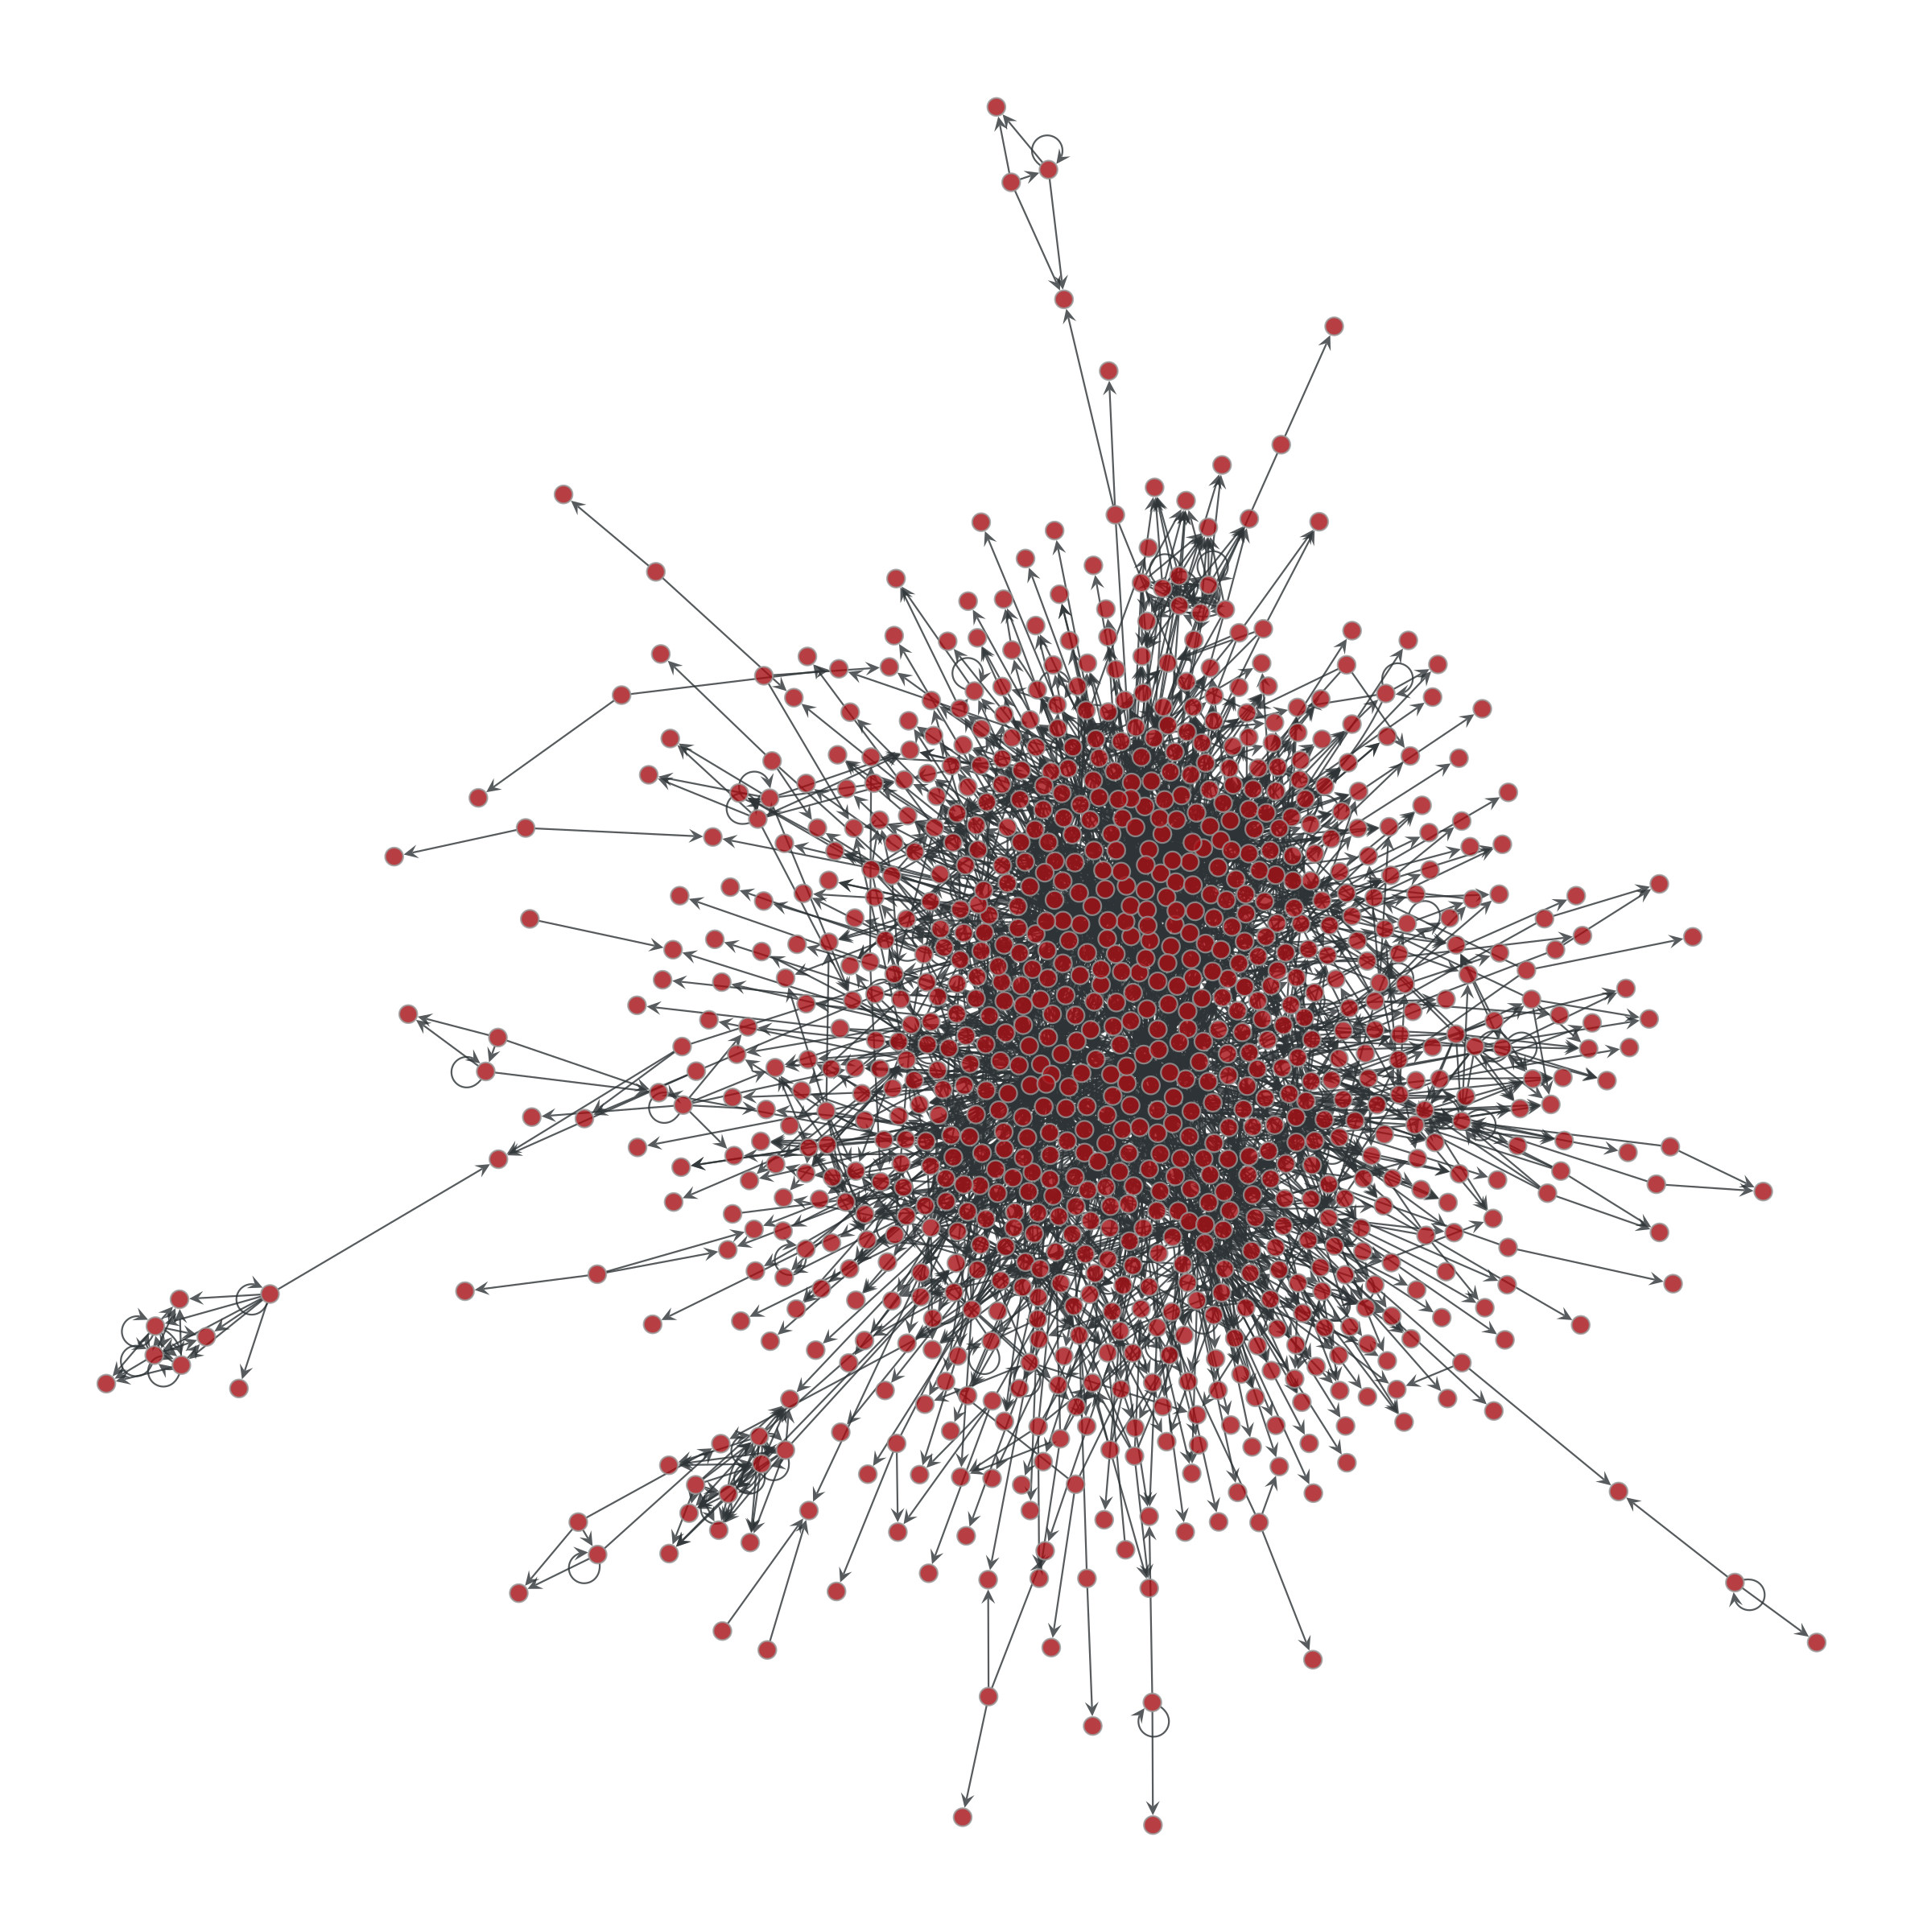

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x1105f2780, at 0x1103cc440>

In [ ]:
from graph_tool.all import *
import matplotlib
import numpy as np

#g = extract_largest_component(g, directed=False)
pos = sfdp_layout(g)


dprms = dict(fmt="png",  output_size=(1200, 1200))

graph_draw(g, pos, **dprms)
        #    , vertex_fill_color=g.vp.value, vcmap=matplotlib.cm.coolwarm,
        #    vcnorm=matplotlib.colors.Normalize(vmin=0, vmax=1), **dprms)

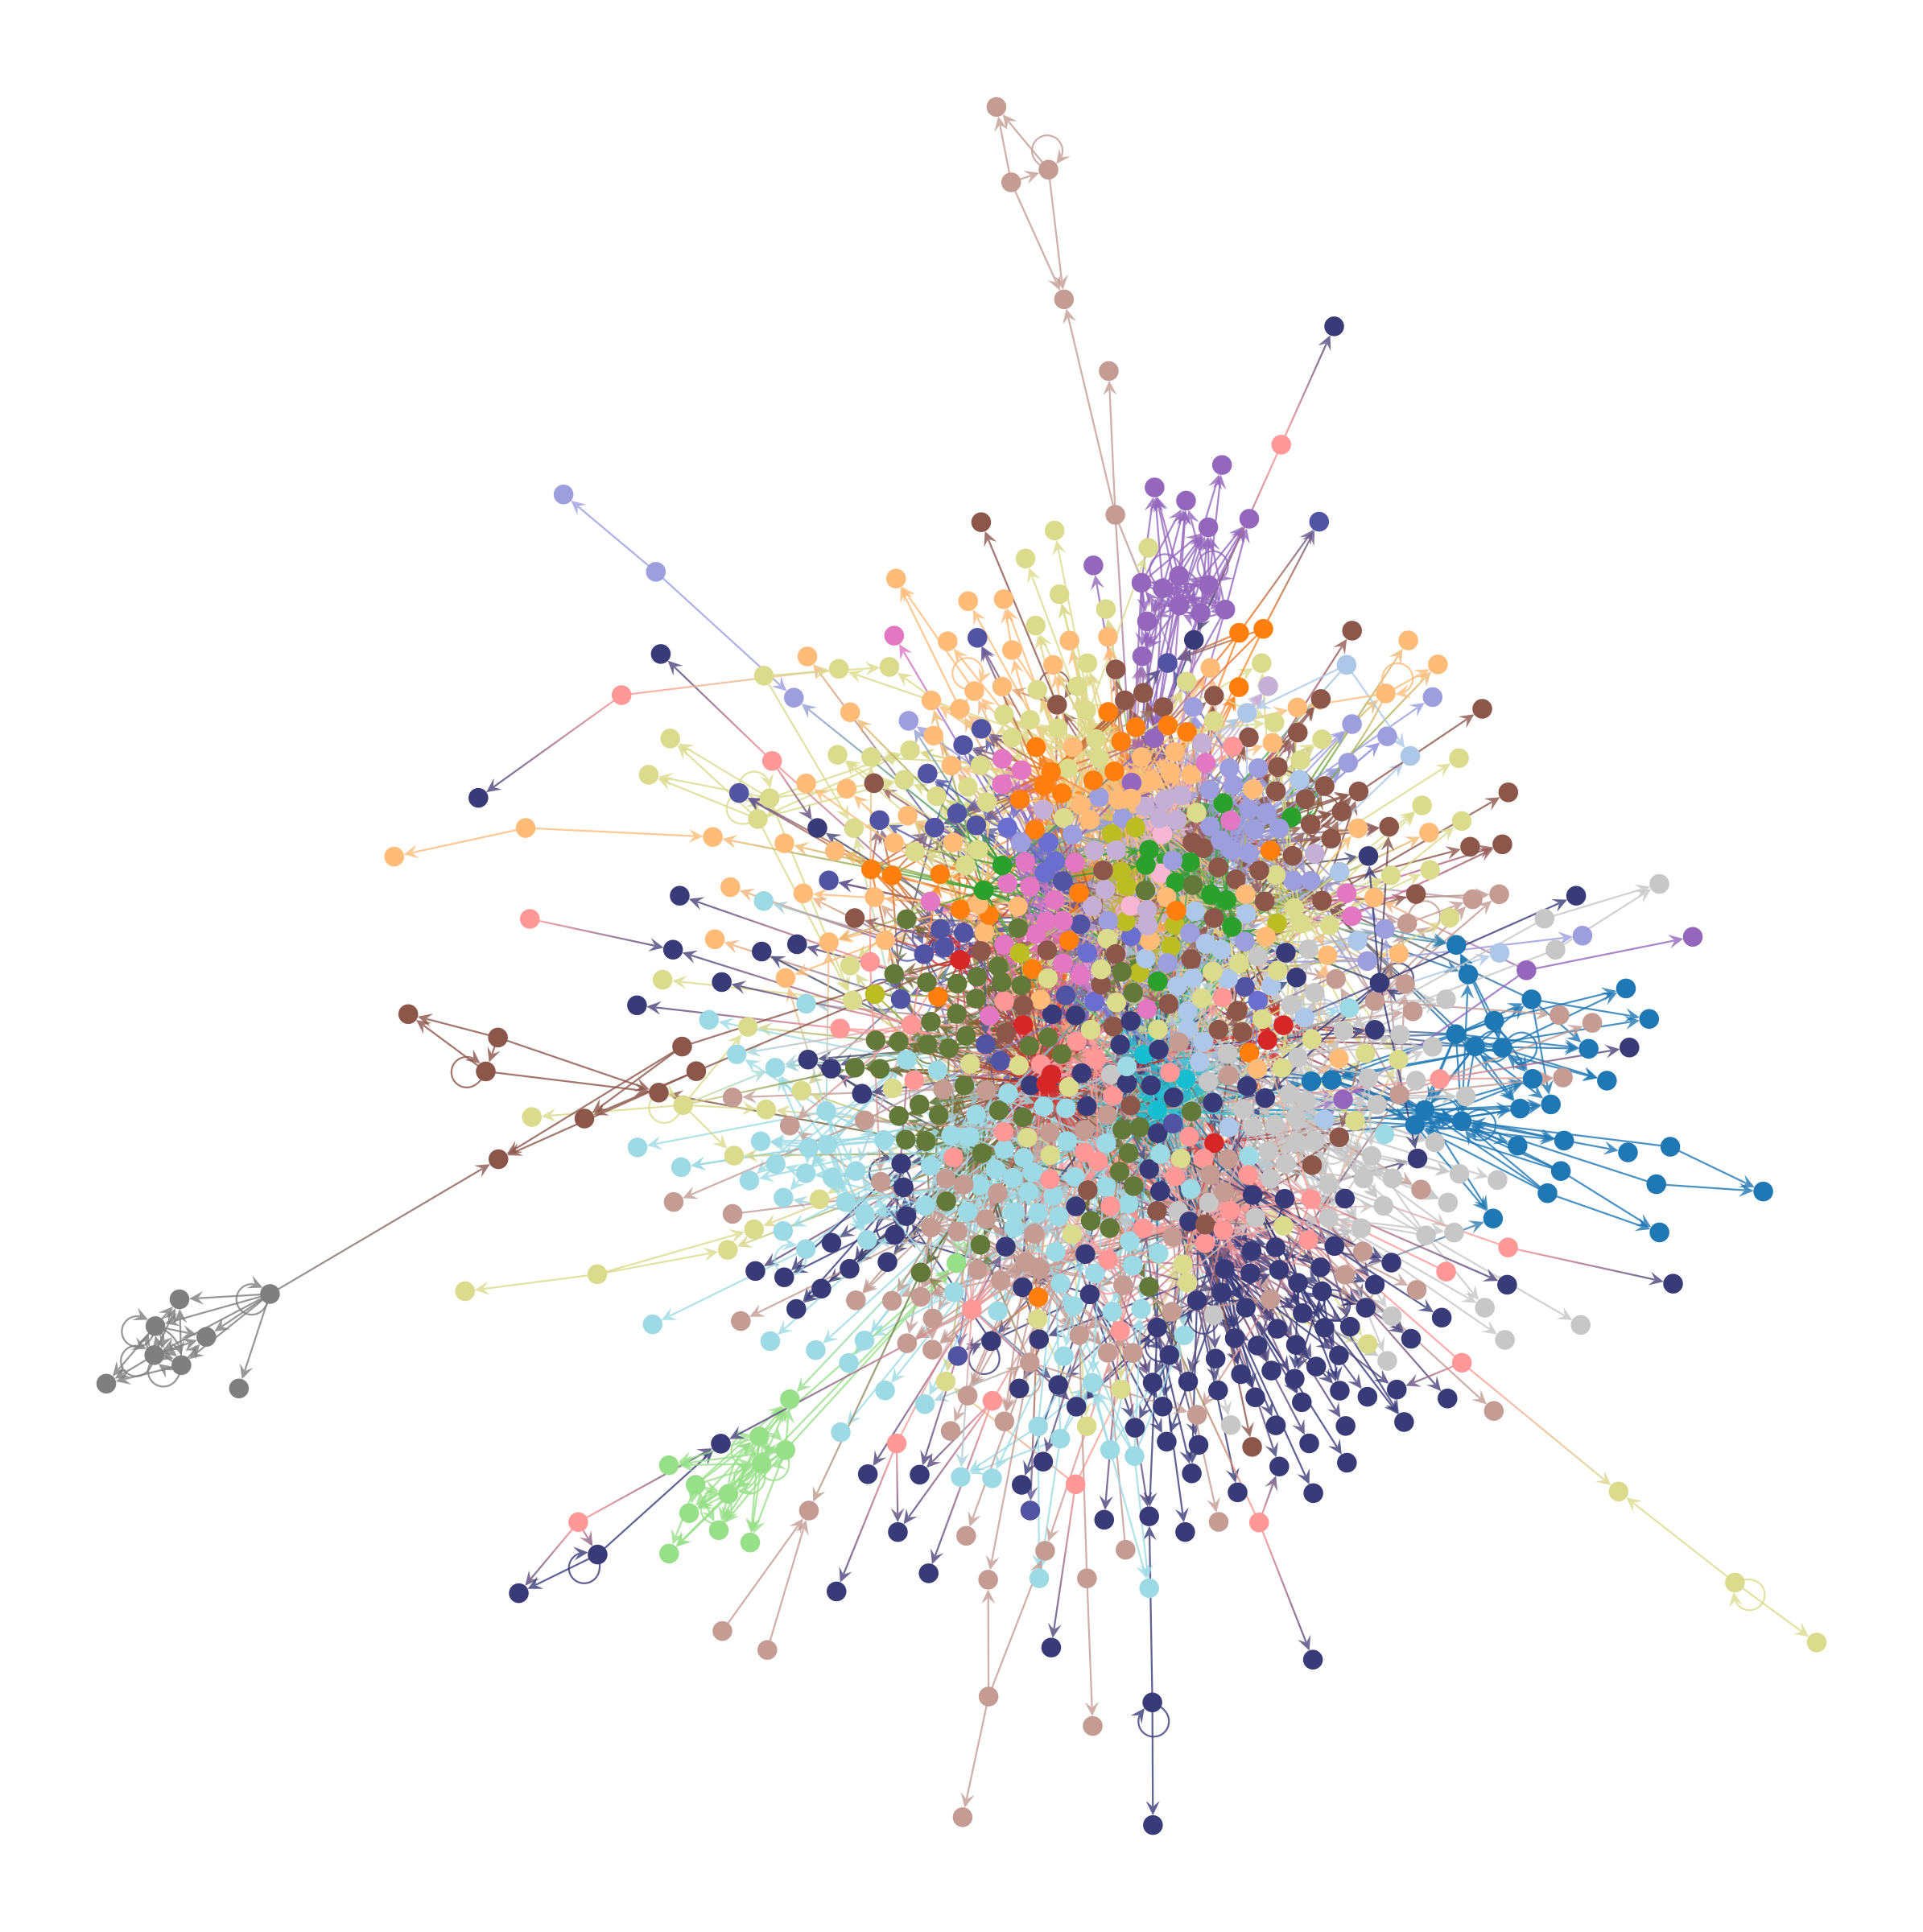

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x1105f2780, at 0x16e5589e0>

In [ ]:
state = minimize_nested_blockmodel_dl(g)
state.levels[0].draw(pos=pos, **dprms)

In [ ]:
pos2 = sfdp_layout(g, groups=state.levels[0].b, gamma=.04)


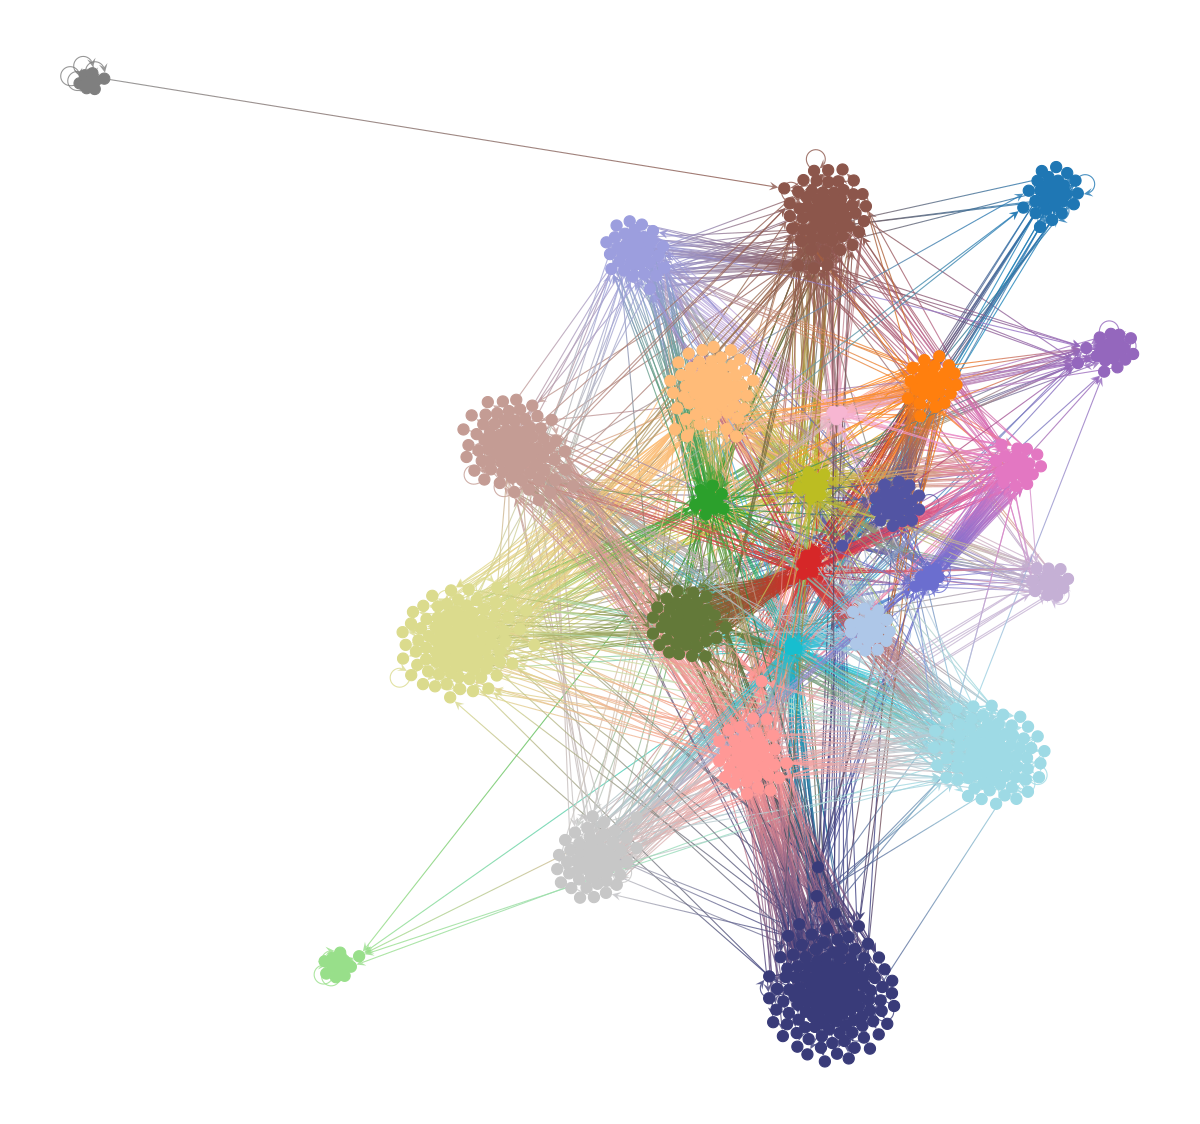

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x1105f2780, at 0x2cb95bec0>

In [ ]:
state.levels[0].draw(pos=pos2)#, edge_gradient=[], edge_color="#33333322", **dprms)

In [ ]:
#!pip install umap-learn
#!pip install sentence-transformers



array([[33.14719583, 45.65824045],
       [-0.25840035, 18.22205357],
       [25.13483712, 56.12786488],
       ...,
       [63.84164818, 64.0880985 ],
       [60.84540791, 64.56216927],
       [65.10097609, 56.93335603]])

In [ ]:
texts_to_embedd = [
    ' '.join([y.title() if y else '' for y in G.nodes(data=True)[x].get('titles', [])])
    for x in G.nodes()
]

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-mpnet-base-v2")#allenai-specter


embeddings = model.encode(texts_to_embedd, show_progress_bar=True, batch_size=10)

# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.decomposition import TruncatedSVD

# vectorizer = TfidfVectorizer(stop_words='english',norm='l1')
# embeddings = vectorizer.fit_transform(texts_to_embedd)

# # Initialize the SVD object
# svd = TruncatedSVD(n_components=100)
# SVD_embedding = svd.fit_transform(vectors)

/Users/Noich001/miniforge3/envs/network_epist_playground/lib/python3.12/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


: 

[478,
 267,
 162,
 162,
 521,
 923,
 521,
 521,
 716,
 923,
 162,
 162,
 267,
 162,
 162,
 478,
 344,
 716,
 521,
 794,
 521,
 86,
 344,
 923,
 521,
 521,
 521,
 521,
 521,
 521,
 521,
 192,
 521,
 344,
 716,
 716,
 267,
 521,
 818,
 389,
 86,
 344,
 839,
 923,
 716,
 270,
 344,
 794,
 521,
 521,
 794,
 162,
 716,
 192,
 192,
 344,
 389,
 478,
 389,
 794,
 151,
 456,
 162,
 716,
 107,
 716,
 716,
 344,
 334,
 344,
 344,
 344,
 344,
 344,
 344,
 267,
 162,
 456,
 716,
 162,
 456,
 521,
 262,
 262,
 86,
 839,
 262,
 262,
 839,
 267,
 839,
 262,
 456,
 86,
 98,
 456,
 456,
 456,
 456,
 456,
 456,
 456,
 107,
 86,
 86,
 86,
 334,
 334,
 98,
 107,
 839,
 839,
 839,
 389,
 98,
 98,
 96,
 389,
 389,
 716,
 839,
 86,
 86,
 98,
 270,
 839,
 253,
 253,
 86,
 262,
 456,
 98,
 270,
 270,
 794,
 818,
 270,
 270,
 86,
 96,
 456,
 818,
 818,
 262,
 270,
 270,
 98,
 98,
 262,
 262,
 96,
 96,
 923,
 456,
 456,
 270,
 923,
 389,
 389,
 262,
 818,
 270,
 716,
 98,
 98,
 923,
 98,
 98,
 270,
 262,
 456,
 

In [ ]:
#

import matplotlib.pyplot as plt
import umap


graph_labels= state.levels[0].get_blocks()

# Apply UMAP
reducer = umap.UMAP(n_neighbors=50, min_dist=0.5, metric='cosine',
                    target_weight=.3,
                    init=np.array(pos2))
embedding = reducer.fit_transform(embeddings, y=graph_labels)

<Figure size 800x800 with 0 Axes>

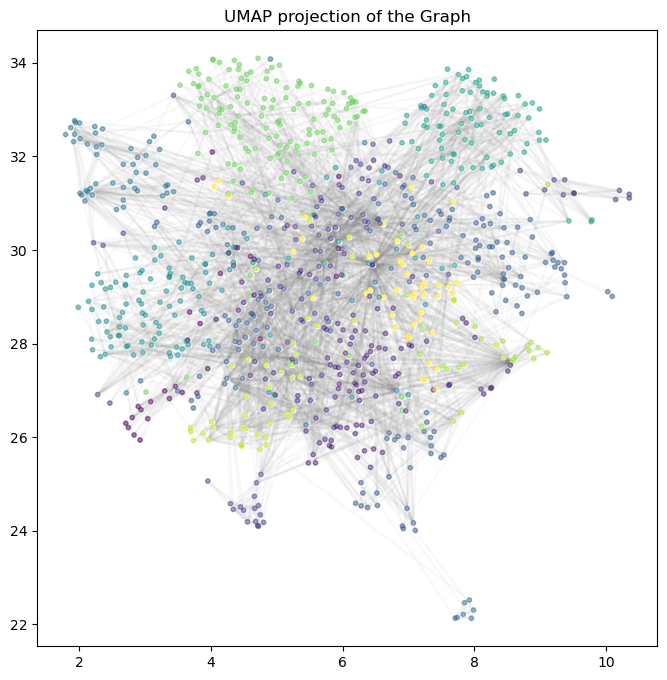

In [ ]:
# Plotting
plt.figure(figsize=(8, 8))


# Prepare a mapping of node labels to indices for embedding
node_list = list(G.nodes())
node_to_index = {node: idx for idx, node in enumerate(node_list)}

# Plotting
plt.figure(figsize=(8, 8))

# Draw edges
for edge in G.edges():
    # Convert node labels to indices for the embedding
    points = embedding[[node_to_index[edge[0]], node_to_index[edge[1]]]]
    plt.plot(points[:, 0], points[:, 1], 'grey', alpha=0.05,zorder=1)

# Draw nodes
plt.scatter(embedding[:, 0], embedding[:, 1], c='white', s=10,alpha=1,zorder=2)

plt.scatter(embedding[:, 0], embedding[:, 1], c=list(graph_labels), s=10,alpha=.5,zorder=3)

plt.title('UMAP projection of the Graph')
plt.show()

In [ ]:

import datamapplot
plot = datamapplot.create_interactive_plot(
embedding,[str(x) for x in graph_labels],
hover_text=texts_to_embedd,use_medoids=True,
    width=800,
    height=800,    point_radius_min_pixels=1,
    point_radius_max_pixels=4,

)
plot



/Users/Noich001/miniforge3/envs/network_epist_playground/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


<InteractiveFigure width=800 height=800>

In [ ]:
#!pip install pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.0/26.0 MB 71.3 MB/s eta 0:00:0000:0100:01


In [ ]:
!pip install dill

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 2.7 MB/s eta 0:00:00a 0:00:01


In [ ]:
import dill

with open('perceptron_graph_pre_1979.pkl', 'wb') as f:
    dill.dump(G, f)

In [ ]:
import dill

# Use dill to deserialize the graph from a file
with open('perceptron_graph_pre_1979.pkl', 'rb') as f:
    G_loaded = dill.load(f)
print(G_loaded.nodes(data=True))

[('https://openalex.org/A5076896748', {'authored_paper_count': 6, 'cited_count': 124, 'titles': ['The perceptron: A probabilistic model for information storage and organization in the brain.', 'PRINCIPLES OF NEURODYNAMICS. PERCEPTRONS AND THE THEORY OF BRAIN MECHANISMS', 'Analysis of a Four-Layer Series-Coupled Perceptron. II', 'The perceptron: A probabilistic model for information storage and organization in the brain.', 'Perceptron Simulation Experiments', 'PRINCIPLES OF NEURODYNAMICS. PERCEPTRONS AND THE THEORY OF BRAIN MECHANISMS', 'Perceptron Simulation Experiments', 'The perceptron: A probabilistic model for information storage and organization in the brain.', 'PRINCIPLES OF NEURODYNAMICS. PERCEPTRONS AND THE THEORY OF BRAIN MECHANISMS', 'PRINCIPLES OF NEURODYNAMICS. PERCEPTRONS AND THE THEORY OF BRAIN MECHANISMS', 'Analysis of a Four-Layer Series-Coupled Perceptron. II', 'PRINCIPLES OF NEURODYNAMICS. PERCEPTRONS AND THE THEORY OF BRAIN MECHANISMS', 'Analysis of a Four-Layer Seri